# LSTM Car Registrations Forecast
This notebook builds an LSTM model to forecast car registrations using a 12-step lookback window with MinMax scaling applied after train-test split.

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.tsa.stattools import adfuller
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

## Load the CSV Dataset

In [2]:
# Load the dataset
df = pd.read_csv('car_registrations.csv')

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f"Dataset shape before outlier removal: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nLast 5 rows:")
print(df.tail())

z_scores = np.abs(zscore(df['Car_Registrations']))

df['Car_Registrations'] = np.where(
    z_scores > 3,
    np.nan,
    df['Car_Registrations']
)

df['Car_Registrations'] = df['Car_Registrations'].interpolate()
print(f"\nFirst 5 rows after outlier smoothing:")
print(df.head())
print(f"\nLast 5 rows after outlier smoothing:")
print(df.tail())

Dataset shape before outlier removal: (316, 2)

First 5 rows:
        Date  Car_Registrations
0 2000-01-01              26064
1 2000-02-01              23929
2 2000-03-01              32057
3 2000-04-01              29513
4 2000-05-01              31176

Last 5 rows:
          Date  Car_Registrations
311 2025-12-01              96970
312 2026-01-01              67995
313 2026-02-01              56690
314 2026-03-01              67846
315 2026-04-01              77869

First 5 rows after outlier smoothing:
        Date  Car_Registrations
0 2000-01-01            26064.0
1 2000-02-01            23929.0
2 2000-03-01            32057.0
3 2000-04-01            29513.0
4 2000-05-01            31176.0

Last 5 rows after outlier smoothing:
          Date  Car_Registrations
311 2025-12-01            72935.5
312 2026-01-01            67995.0
313 2026-02-01            56690.0
314 2026-03-01            67846.0
315 2026-04-01            77869.0


## Parse Dates and Sort Data

In [3]:
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Total months after outlier removal: {len(df)}")

Date range: 2000-01-01 00:00:00 to 2026-04-01 00:00:00
Total months after outlier removal: 316


## Create Time Series Index and Target

In [4]:
# Set date as index and create the log-transformed target
df.set_index('Date', inplace=True)
df['log_car_reg'] = np.log(df['Car_Registrations'])
log_series = df['log_car_reg']
print("Log transformation applied to Car_Registrations.")

def run_adf_test(series, alpha=0.05):
    result = adfuller(series, autolag='AIC')
    print(f"ADF statistic: {result[0]:.4f}, p-value: {result[1]:.4f}, usedlag: {result[2]}, nobs: {result[3]}")
    return result[1] <= alpha

difference_order = 0
processed_series = log_series.copy()
print("\nADF test on log-transformed series:")
if not run_adf_test(processed_series):
    processed_series = processed_series.diff().dropna()
    difference_order = 1
    print("Series was not stationary. Applied first-order differencing.")
    print("\nADF test after first differencing:")
    if not run_adf_test(processed_series):
        processed_series = processed_series.diff().dropna()
        difference_order = 2
        print("Series still not stationary. Applied second-order differencing.")
        print("\nADF test after second differencing:")
        if not run_adf_test(processed_series):
            print("Warning: series is still non-stationary after second differencing.")

if difference_order == 0:
    print("\nFinal series uses log-transformed values with no differencing.")
else:
    print(f"\nFinal series uses log-transformed values with differencing order = {difference_order}.")

print(f"Final processed data length: {len(processed_series)}")
data = processed_series.values.reshape(-1, 1)
print(f"Data shape: {data.shape}")


Log transformation applied to Car_Registrations.

ADF test on log-transformed series:
ADF statistic: -1.6004, p-value: 0.4834, usedlag: 14, nobs: 301
Series was not stationary. Applied first-order differencing.

ADF test after first differencing:
ADF statistic: -8.9735, p-value: 0.0000, usedlag: 13, nobs: 301

Final series uses log-transformed values with differencing order = 1.
Final processed data length: 315
Data shape: (315, 1)


## Split Data into Train and Test (Last 64 Months)

In [5]:
# Split into train (all but last 64) and test (last 64 months)
test_size = 64
train_data = data[:-test_size]
test_data = data[-test_size:]

print(f"Train data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")
print(f"Train range: {len(train_data)} months")
print(f"Test range: {len(test_data)} months")



Train data shape: (251, 1)
Test data shape: (64, 1)
Train range: 251 months
Test range: 64 months


## Scale Data with MinMaxScaler After Split

In [6]:
# Create scaler and fit on training data only
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

print(f"Scaled train shape: {train_scaled.shape}")
print(f"Scaled test shape: {test_scaled.shape}")
print(f"Scaler min: {scaler.data_min_[0]:.2f}, max: {scaler.data_max_[0]:.2f}")

Scaled train shape: (251, 1)
Scaled test shape: (64, 1)
Scaler min: -0.82, max: 0.65


## Create LSTM Input Sequences

In [7]:
import numpy as np

def create_sequences(data, lookback=24):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, 0:1])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

lookback = 12

X_train, y_train = create_sequences(train_scaled, lookback)

test_extended = np.vstack((train_scaled[-lookback:], test_scaled))
X_test, y_test = create_sequences(test_extended, lookback)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

print(f"X_train shape: {X_train.shape}")



print(f"Selected lookback from ACF: {lookback}")
X_test, y_test = create_sequences(test_extended, lookback)

test_extended = np.vstack((train_scaled[-lookback:], test_scaled))

X_train, y_train = create_sequences(train_scaled, lookback)

X_train shape: (239, 12, 1)
X_test shape: (64, 12, 1)
X_train shape: (239, 12, 1)
X_test shape: (64, 12, 1)
X_train shape: (239, 12, 1)
Selected lookback from ACF: 12


## Build the LSTM Model

In [8]:
model = Sequential([
    LSTM(
        16,
        input_shape=(
            lookback,
            1
        )
    ),

    Dense(
        8,
        activation='relu'
    ),

    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

print("Model Architecture:")
print(model.summary())

Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,297 (5.07 KB)

 Trainable params: 1,297 (5.07 KB)

 Non-trainable params: 0 (0.00 B)

None


## Train the Model

In [9]:
from tensorflow.keras.callbacks import EarlyStopping

print("Training the LSTM model with walk-forward validation...")



# Build a fresh compiled model for each fold

def create_model(lookback=12):
    model = Sequential([
        LSTM(16, input_shape=(lookback, 1)),
        Dense(8, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model


def walk_forward_validation(scaled_data, lookback=12, val_size=12, n_splits=5):
    total_len = len(scaled_data)
    max_splits = (total_len - lookback - val_size) // val_size
    if max_splits < 1:
        raise ValueError("Not enough data for walk-forward validation with the given parameters.")

    n_splits = min(n_splits, max_splits)
    metrics = []

    for split in range(n_splits):
        initial_train_size = 120
        train_end = initial_train_size + (split + 1) * val_size
        val_start = train_end
        val_end = val_start + val_size

        train_window = scaled_data[:train_end]
        val_window = scaled_data[val_start:val_end]

        X_train_w, y_train_w = create_sequences(train_window, lookback)
        X_val_w, y_val_w = create_sequences(
            np.vstack((train_window[-lookback:], val_window)),
            lookback
        )

        fold_model = create_model(lookback)
        fold_model.fit(
            X_train_w,
            y_train_w,
            epochs=100,
            batch_size=16,
            validation_data=(X_val_w, y_val_w),
            callbacks=[EarlyStopping(
                monitor='val_loss',
                patience=30,
                restore_best_weights=True,
                verbose=1
            )],
            shuffle=False,
            verbose=0
        )

        y_val_pred = fold_model.predict(X_val_w, verbose=0)
        mse = mean_squared_error(y_val_w, y_val_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_val_w, y_val_pred)
        metrics.append((mse, rmse, r2))

        print(
            f"Fold {split + 1}: train_end={train_end}, val_end={val_end}, "
            f"MSE={mse:.6f}, RMSE={rmse:.6f}, R²={r2:.6f}"
        )

    return metrics

metrics = walk_forward_validation(train_scaled, lookback=lookback, val_size=12, n_splits=5)

mse_values = [m[0] for m in metrics]
rmse_values = [m[1] for m in metrics]
r2_values = [m[2] for m in metrics]

print("\nWalk-forward validation summary:")
print(f"Average MSE:  {np.mean(mse_values):.6f}")
print(f"Average RMSE: {np.mean(rmse_values):.6f}")
print(f"Average R²:   {np.mean(r2_values):.6f}")

print("\nTraining final model on the full training set...")
model = create_model(lookback)
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split = 0.15,
    shuffle=False,
    verbose=1
)

print("\nTraining completed!")

Training the LSTM model with walk-forward validation...


Epoch 43: early stopping
Restoring model weights from the end of the best epoch: 13.
Fold 1: train_end=132, val_end=144, MSE=0.026604, RMSE=0.163109, R²=-0.002621
Restoring model weights from the end of the best epoch: 98.
Fold 2: train_end=144, val_end=156, MSE=0.005788, RMSE=0.076078, R²=0.248318
Restoring model weights from the end of the best epoch: 100.
Fold 3: train_end=156, val_end=168, MSE=0.009837, RMSE=0.099183, R²=0.234614
Restoring model weights from the end of the best epoch: 100.
Fold 4: train_end=168, val_end=180, MSE=0.005892, RMSE=0.076762, R²=0.334940
Restoring model weights from the end of the best epoch: 100.
Fold 5: train_end=180, val_end=192, MSE=0.011187, RMSE=0.105768, R²=0.443817

Walk-forward validation summary:
Average MSE:  0.011862
Average RMSE: 0.104180
Average R²:   0.251814

Training final model on the full training set...
Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0480 - val_loss: 0.0392
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/s

## Evaluate with MSE, RMSE, and R2

In [10]:
# Make predictions on test set
y_pred_scaled = model.predict(X_test, verbose=0)

# Calculate metrics on scaled data
mse_scaled = mean_squared_error(y_test, y_pred_scaled)
rmse_scaled = np.sqrt(mse_scaled)
r2_scaled = r2_score(y_test, y_pred_scaled)

print("=== Metrics on Scaled Data ===")
print(f"MSE (scaled):  {mse_scaled:.6f}")
print(f"RMSE (scaled): {rmse_scaled:.6f}")
print(f"R² (scaled):   {r2_scaled:.6f}")

# Save model
model.save("lstm_model_car_forecast.keras")

=== Metrics on Scaled Data ===
MSE (scaled):  0.049779
RMSE (scaled): 0.223112
R² (scaled):   -0.094613


## Inverse Scale Predictions

In [11]:


y_pred_log = scaler.inverse_transform(y_pred_scaled)

y_pred_diff = scaler.inverse_transform(y_pred_scaled)

if difference_order == 1:
    previous_actual_logs = log_series.iloc[-test_size - 1:-1].values.reshape(-1, 1)
    y_pred_log_values = previous_actual_logs + y_pred_diff
    y_test_log_values = log_series.iloc[-test_size:].values.reshape(-1, 1)
elif difference_order == 0:
    y_pred_log_values = y_pred_diff
    y_test_log_values = log_series.iloc[-test_size:].values.reshape(-1, 1)
else:
    prev1 = log_series.iloc[-test_size - 1:-1].values.reshape(-1, 1)
    prev2 = log_series.iloc[-test_size - 2:-2].values.reshape(-1, 1)
    y_pred_log_values = y_pred_diff + 2 * prev1 - prev2
    y_test_log_values = log_series.iloc[-test_size:].values.reshape(-1, 1)

y_pred_original = np.exp(y_pred_log_values)
y_test_original = np.exp(y_test_log_values)

mse_original = mean_squared_error(y_test_original, y_pred_original)
rmse_original = np.sqrt(mse_original)
r2_original = r2_score(y_test_original, y_pred_original)

assert y_pred_original.shape == y_test_original.shape, \
    f"Shape mismatch! Preds: {y_pred_original.shape}, Actuals: {y_test_original.shape}"

print("=== Metrics on Original Scale ===")
print(f"MSE (original):  {mse_original:.2f}")
print(f"RMSE (original): {rmse_original:.2f}")
print(f"R² (original):   {r2_original:.6f}")


=== Metrics on Original Scale ===
MSE (original):  185284236.84
RMSE (original): 13611.92
R² (original):   0.129863


## Plot Prediction vs Actual

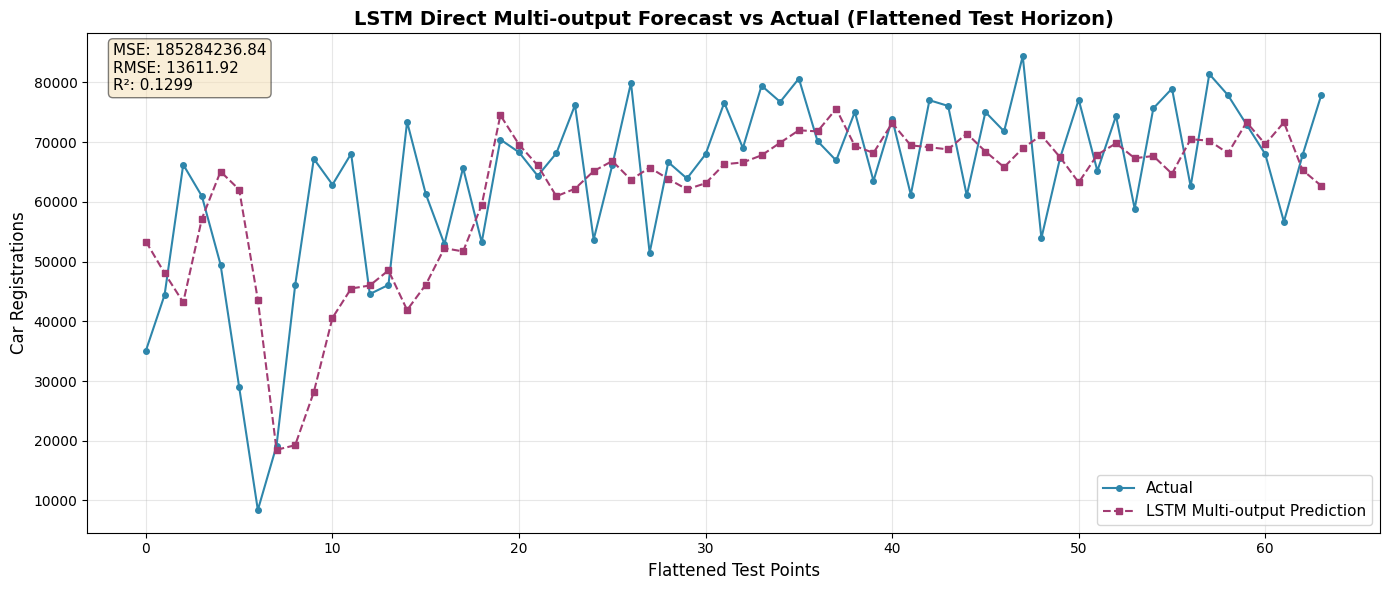


✓ Direct multi-step forecast completed successfully!


In [12]:
# Create prediction vs actual plot
plt.figure(figsize=(14, 6))

# Plot flattened actual values and predictions
plt.plot(y_test_original.flatten(), marker='o', linestyle='-', 
         linewidth=1.5, label='Actual', color='#2E86AB', markersize=4)
plt.plot(y_pred_original.flatten(), marker='s', linestyle='--', 
         linewidth=1.5, label='LSTM Multi-output Prediction', color='#A23B72', markersize=4)

plt.title('LSTM Direct Multi-output Forecast vs Actual (Flattened Test Horizon)', fontsize=14, fontweight='bold')
plt.xlabel('Flattened Test Points', fontsize=12)
plt.ylabel('Car Registrations', fontsize=12)
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)

# Add metrics to the plot
metrics_text = f'MSE: {mse_original:.2f}\nRMSE: {rmse_original:.2f}\nR²: {r2_original:.4f}'
plt.text(0.02, 0.98, metrics_text, transform=plt.gca().transAxes, 
         fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"\n✓ Direct multi-step forecast completed successfully!")